# Belief in physics: data → transformer → analysis

One portable experimental notebook in three phases. It trains from the current physics implementation only; old checkpoints and old result files are never loaded.

## Notation

- **`m` — impulse cycles**: number of impulse cycles in one trajectory. One HMM letter selects the impulse at the start of each cycle.
- **`n` — impulse spacing**: number of physics timestamps/tokens from one impulse to the next. Every trajectory therefore contains exactly `m × n` tokens.
- **`k` — lookahead**: at position `t`, the model is trained to predict token `t + k`; `k=1` is ordinary next-token prediction and `k=n+1` skips one full impulse cycle plus one timestamp.
- **`dt` — physics sampling gap**: simulated time between output tokens. The physics may use a smaller `integration_dt`; for example `integration_dt=0.01` and `dt=0.05` execute five physics iterations before emitting each token.

## Universal experiment interface

This cell runs unchanged on a local checkout or Kaggle. On Kaggle it first looks for an attached repository dataset under `/kaggle/input`; if none is attached, it clones `physics-fix-and-improvements` into `/kaggle/working`, so Internet must be enabled for that fallback. Outputs always go to writable Kaggle working storage.

The notebook interface is made of immutable dataclasses. Edit the selected class instance near the bottom of the cell; the remaining phases consume those objects without system-specific branches. Smoke mode reduces expensive counts while preserving the same pipeline.

### Class reference

| Class | Behavior and extension point |
|---|---|
| `HMMConfig` | Defines the number of hidden HMM states/actions, emission accuracy `alpha`, and HMM-state persistence `stay`; validates probabilities and builds the exact HMM. |
| `InitialStateConfig` | Chooses fixed or randomized initial states and applies system-aware bounds after jitter. |
| `PhysicsSystemConfig` | Common interface for physics sampling gap `dt`, internal `integration_dt`, perturbation magnitude `delta_v`, observation bins, validation, and simulator construction. |
| `SampledPhysicsSystem` | Wraps a simulator so every emitted token advances it by `dt/integration_dt` internal iterations. |
| `PendulumConfig` | Configures gravity, length, viscous damping, velocity bound, and release state for the damped pendulum. |
| `PredatorPreyConfig` | Configures growth, interaction, mortality, self-limitation, population bounds, and initial populations. |
| `SphereConfig` | Configures the spherical pendulum’s gravity, length, sliding friction, rate bound, release angle, and azimuthal rate. |
| `DoublePendulumConfig` | Configures lengths, masses, joint damping, velocity bound, kick gain, and four-dimensional release state. |
| `ExperimentConfig` | Composes one physics system, one HMM, initial-state policy, trajectory count, `m`, and `n`; the resulting sequence length is asserted to equal `m × n`. |
| `TrainingConfig` | Defines one transformer architecture, optimizer run, and lookahead `k`; converts itself into the executable model/training configuration. |
| `AnalysisConfig` | Defines probe data volume, grouped cross-validation, ridge penalties, held-out fraction, layer choice, and four feature formats. |
| `MessKProcess` | Core exact HMM built by `HMMConfig`; samples HMM states/letters and computes normalized predictive beliefs. |
| `MessDriven` | Core composition built by `ExperimentConfig`; maps HMM letters to physical kicks, integrates dynamics, and discretizes observations. |
| `LookaheadTransformer` | Decoder-only causal model whose loss shifts targets by `k`, so logits at position `t` predict token `t+k`. |
| `PhysicsDataset` | Finite diagnostic dataset used for shape/dtype inspection; training instead streams fresh batches. |

To change systems, replace `PendulumConfig(...)` with another concrete physics class. To add a new system later, implement the simulator protocol in the core package and add one small `PhysicsSystemConfig` subclass here.

### Typical team edits

- Change damping, gravity, release state, physics sampling gap `dt`, internal accuracy `integration_dt`, `delta_v`, or bins on the selected physics class.
- Change hidden-process behavior with `HMMConfig(n_states=..., alpha=..., stay=...)`; current physics classes expose four actions and therefore require `n_states=4`.
- Change trajectory structure and data volume with `ExperimentConfig(m=..., n=..., n_trajectories=...)`.
- Change forecast horizon with `TrainingConfig(k=...)`; add instances to `TRAINING_CONFIGS` to compare horizons, architectures, or seeds.
- Change probe cost and evaluation rigor through `AnalysisConfig`; trajectory groups remain disjoint by construction.

In [ ]:
%matplotlib inline

import json, os, subprocess, sys
from dataclasses import asdict, dataclass, field, fields
from pathlib import Path
from typing import ClassVar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

REPO_URL = 'https://github.com/ManjotSingh08x/Belief-in-physics.git'
REPO_BRANCH = 'physics-fix-and-improvements'
IS_KAGGLE = Path('/kaggle').exists()

def locate_repo():
    configured = os.environ.get('BELIEF_REPO_ROOT')
    candidates = ([Path(configured)] if configured else []) + [Path.cwd(), Path.cwd().parent]
    if IS_KAGGLE:
        candidates.append(Path('/kaggle/working/Belief-in-physics'))
        input_root = Path('/kaggle/input')
        if input_root.exists():
            candidates.extend(marker.parents[1] for marker in input_root.rglob('physics/messk.py'))
    for candidate in candidates:
        if (candidate / 'physics' / 'messk.py').exists():
            return candidate.resolve()
    if not IS_KAGGLE:
        raise FileNotFoundError('Run inside the repository or set BELIEF_REPO_ROOT.')
    target = Path('/kaggle/working/Belief-in-physics')
    if target.exists():
        raise FileNotFoundError(f'{target} exists but is not a valid repository checkout')
    subprocess.run(['git', 'clone', '--depth', '1', '--branch', REPO_BRANCH, REPO_URL, str(target)], check=True)
    return target

ROOT = locate_repo()
sys.path.insert(0, str(ROOT))

from models.analysis import residual_streams_batched, tick_features
from models.explore import next_token_probs as token_probabilities
from models.train import TrainConfig as CoreTrainConfig, pick_device, train
from models.transformer import ModelConfig, TinyTransformer
from physics import visualise as V
from physics.messk import MessDriven, MessKProcess, simplex_embedding
from physics.systems.double_pendulum import DoublePendulum
from physics.systems.pendulum import Pendulum
from physics.systems.predator_prey import PredatorPrey
from physics.systems.sphere import SphereBall, THETA_MAX, THETA_MIN

@dataclass(frozen=True)
class HMMConfig:
    """Hidden process: HMM-state/action count, emission accuracy, and state persistence."""
    n_states: int = 4
    alpha: float = 0.7
    stay: float = 0.7

    def validate(self):
        if self.n_states < 2 or not 0 <= self.alpha <= 1 or not 0 <= self.stay <= 1:
            raise ValueError(f'invalid HMM configuration: {self}')

    def build(self):
        self.validate()
        return MessKProcess(n_states=self.n_states, alpha=self.alpha, stay=self.stay)


@dataclass(frozen=True)
class InitialStateConfig:
    """Fixed release or bounded Gaussian randomization around the system release state."""
    mode: str = 'fixed'
    jitter_std: float = 0.10

    def validate(self):
        if self.mode not in {'fixed', 'random'} or self.jitter_std < 0:
            raise ValueError(f'invalid initial-state configuration: {self}')

    def sample(self, system, rng, batch_size):
        self.validate()
        z = system.initial_state(batch_size).astype(np.float64, copy=True)
        if self.mode == 'fixed':
            return z
        z += rng.normal(0.0, self.jitter_std, size=z.shape)
        names = tuple(system.state_names)
        if hasattr(system, 'log_bound'):
            z = np.clip(z, -system.log_bound, system.log_bound)
        if hasattr(system, 'omega_max'):
            for index, name in enumerate(names):
                if 'omega' in name:
                    z[:, index] = np.clip(z[:, index], -system.omega_max, system.omega_max)
        if hasattr(system, 'rate_max'):
            z[:, names.index('theta')] = np.clip(z[:, names.index('theta')], THETA_MIN, THETA_MAX)
            z[:, names.index('psi')] = (z[:, names.index('psi')] + np.pi) % (2 * np.pi) - np.pi
            for name in ('dtheta', 'dpsi'):
                z[:, names.index(name)] = np.clip(z[:, names.index(name)], -system.rate_max, system.rate_max)
        return z


@dataclass(frozen=True)
class PhysicsSystemConfig:
    """Common driver controls and construction protocol for one physical system."""
    system_name: ClassVar[str] = 'abstract'
    dt: float = 0.02
    integration_dt: float = 0.01
    delta_v: float = 0.3
    obs_bins: int | tuple[int, ...] = 181

    def validate(self):
        bins = (self.obs_bins,) if isinstance(self.obs_bins, int) else self.obs_bins
        ratio = self.dt / self.integration_dt if self.integration_dt > 0 else np.nan
        if self.dt <= 0 or self.integration_dt <= 0 or not np.isclose(ratio, round(ratio)):
            raise ValueError('dt must be a positive integer multiple of integration_dt')
        if self.delta_v <= 0 or not bins or any(value < 2 for value in bins):
            raise ValueError(f'invalid physics configuration: {self}')

    def parameters(self):
        driver = {'dt', 'integration_dt', 'delta_v', 'obs_bins'}
        return {item.name: getattr(self, item.name) for item in fields(self) if item.name not in driver}

    def build_system(self):
        raise NotImplementedError('subclasses must construct the simulator')


@dataclass(frozen=True)
class SampledPhysicsSystem:
    """Advance a base simulator with small internal steps, exposing states only every dt."""
    base: object
    integration_dt: float

    def __getattr__(self, name):
        return getattr(self.base, name)

    def flow(self, z, dt, substeps=1):
        internal_steps = round(dt / self.integration_dt)
        if internal_steps < 1 or not np.isclose(dt, internal_steps * self.integration_dt):
            raise ValueError('physics sampling gap dt must be an integer multiple of integration_dt')
        return self.base.flow(z, dt, substeps=internal_steps * substeps)


@dataclass(frozen=True)
class PendulumConfig(PhysicsSystemConfig):
    """Damped pendulum with angular-velocity kicks and theta observations."""
    system_name: ClassVar[str] = 'pendulum'
    dt: float = 0.02
    integration_dt: float = 0.01
    delta_v: float = 0.5477225575051661
    obs_bins: int | tuple[int, ...] = 181
    g: float = 9.8
    length: float = 1.0
    gamma: float = 1.2
    omega_max: float = 8.0
    theta0: float = 0.0
    omega0: float = 1.0

    def build_system(self):
        self.validate()
        return Pendulum(**self.parameters())


@dataclass(frozen=True)
class PredatorPreyConfig(PhysicsSystemConfig):
    """Log-space predator-prey dynamics with logistic prey self-limitation."""
    system_name: ClassVar[str] = 'predator_prey'
    dt: float = 0.05
    integration_dt: float = 0.01
    delta_v: float = 0.35
    obs_bins: int | tuple[int, ...] = 181
    a: float = 1.0
    b: float = 0.6
    c: float = 0.8
    d: float = 0.4
    kappa: float = 5.0
    log_bound: float = 3.5
    x0: float = 3.0
    y0: float = 2.0

    def build_system(self):
        self.validate()
        return PredatorPrey(**self.parameters())


@dataclass(frozen=True)
class SphereConfig(PhysicsSystemConfig):
    """Spherical pendulum with two tangent kicks and Cartesian observations."""
    system_name: ClassVar[str] = 'sphere'
    dt: float = 0.04
    integration_dt: float = 0.01
    delta_v: float = 0.15
    obs_bins: int | tuple[int, ...] = (30, 30)
    g: float = 9.8
    length: float = 1.0
    gamma: float = 0.35
    rate_max: float = 6.0
    theta0: float = 0.6
    psi_dot0: float = 2.0

    def build_system(self):
        self.validate()
        return SphereBall(**self.parameters())


@dataclass(frozen=True)
class DoublePendulumConfig(PhysicsSystemConfig):
    """Chaotic two-joint pendulum with separate damping and kick channels."""
    system_name: ClassVar[str] = 'double_pendulum'
    dt: float = 0.01
    integration_dt: float = 0.01
    delta_v: float = 1.2
    obs_bins: int | tuple[int, ...] = 181
    g: float = 9.8
    l1: float = 1.0
    l2: float = 1.0
    m1: float = 1.0
    m2: float = 1.0
    gamma1: float = 2.5
    gamma2: float = 2.5
    omega_max: float = 10.0
    joint1_action_gain: float = 2.0
    th1_0: float = 0.9
    th2_0: float = -0.4
    w1_0: float = 0.0
    w2_0: float = 0.0

    def build_system(self):
        self.validate()
        return DoublePendulum(**self.parameters())


@dataclass(frozen=True)
class ExperimentConfig:
    """Complete generative experiment: physics + HMM + driver + initial-state policy."""
    name: str
    physics: PhysicsSystemConfig
    hmm: HMMConfig = field(default_factory=HMMConfig)
    initial_state: InitialStateConfig = field(default_factory=InitialStateConfig)
    seed: int = 20260916
    n_trajectories: int = 256
    m: int = 16
    n: int = 10

    @property
    def process_name(self):
        return f'{self.physics.system_name}_mess{self.hmm.n_states}'

    @property
    def trajectory_tokens(self):
        return self.m * self.n

    @property
    def impulse_positions(self):
        return tuple(range(0, self.trajectory_tokens, self.n))

    def validate(self):
        self.physics.validate(); self.hmm.validate(); self.initial_state.validate()
        if self.hmm.n_states != 4:
            raise ValueError('current physical systems expose four actions; keep n_states=4')
        if self.n_trajectories < 1 or self.m < 1 or self.n < 1:
            raise ValueError(f'invalid experiment sizes: {self}')

    def build_process(self):
        self.validate()
        sampled_system = SampledPhysicsSystem(self.physics.build_system(), self.physics.integration_dt)
        process = MessDriven(chain=self.hmm.build(), system=sampled_system,
                          delta_v=self.physics.delta_v, m=self.m, n_steps=self.n,
                          dt=self.physics.dt, obs_bins=self.physics.obs_bins)
        if process.seq_len != self.trajectory_tokens:
            raise AssertionError('trajectory length must equal m * n')
        # process._experiment_config = self
        return process

    def sample_batch(self, proc, rng, batch_size):
        initial = self.initial_state.sample(proc.system, rng, batch_size)
        raw = proc.sample_batch(rng, batch_size, initial_state=initial)
        if raw['tokens'].shape != (batch_size, self.trajectory_tokens) or raw['letters'].shape != (batch_size, self.m):
            raise AssertionError('sampling must produce m impulses and m * n tokens per trajectory')
        batch = {name: raw[name] for name in ('tokens', 'observable', 'metric', 'letters', 'beliefs')}
        batch['hmm_state_path'] = raw['states']
        batch['initial_state'] = initial
        return batch

    def metadata(self):
        data = asdict(self)
        data['physics']['system_name'] = self.physics.system_name
        return data


class LookaheadTransformer(TinyTransformer):
    """Causal transformer trained to predict the token k timestamps ahead."""
    def __init__(self, config, k):
        super().__init__(config)
        self.k = k

    def loss(self, tokens):
        if self.k < 1 or self.k >= tokens.shape[1]:
            raise ValueError(f'lookahead k must satisfy 1 <= k < {tokens.shape[1]}')
        logits = self(tokens)
        return torch.nn.functional.cross_entropy(
            logits[:, :-self.k].reshape(-1, logits.shape[-1]),
            tokens[:, self.k:].reshape(-1),
        )


@dataclass(frozen=True)
class TrainingConfig:
    """One transformer architecture, lookahead target, and optimizer run."""
    name: str = 'single_config'
    seed: int = 0
    k: int = 1
    d_model: int = 64
    n_layers: int = 2
    n_heads: int = 1
    d_mlp: int = 256
    batch_size: int = 128
    total_tokens: int = 2_000_000
    learning_rate: float = 1e-3
    weight_decay: float = 0.0

    def validate(self):
        positive = (self.d_model, self.n_layers, self.n_heads, self.d_mlp, self.batch_size, self.total_tokens)
        if self.k < 1 or min(positive) < 1 or self.d_model % self.n_heads or self.learning_rate <= 0 or self.weight_decay < 0:
            raise ValueError(f'invalid training configuration: {self}')

    def model_config(self, proc):
        self.validate()
        if self.k >= proc.seq_len:
            raise ValueError(f'lookahead k={self.k} must be shorter than sequence length {proc.seq_len}')
        return ModelConfig(vocab_size=proc.n_obs, n_ctx=proc.seq_len, n_layers=self.n_layers,
                           n_heads=self.n_heads, d_model=self.d_model, d_mlp=self.d_mlp, seed=self.seed)

    def build_model(self, proc):
        return LookaheadTransformer(self.model_config(proc), self.k)

    def train_config(self):
        self.validate()
        return CoreTrainConfig(total_tokens=self.total_tokens, batch_size=self.batch_size,
                               learning_rate=self.learning_rate, weight_decay=self.weight_decay,
                               seed=self.seed, log_every=1 if SMOKE else 20, checkpoint_at=())


@dataclass(frozen=True)
class AnalysisConfig:
    """Held-out ridge protocol and the residual-stream feature views to compare."""
    n_trajectories: int = 1024
    cv_folds: int = 5
    ridge_alphas: tuple[float, ...] = (0.1, 1.0, 10.0, 100.0, 1000.0)
    test_fraction: float = 0.2
    selected_layer: int = -1
    probe_modes: tuple[str, ...] = ('single_layer_single_token', 'all_layers_single_token',
                                         'single_layer_cycle', 'all_layers_cycle')

    def validate(self):
        if self.n_trajectories < self.cv_folds + 1 or self.cv_folds < 2 or not 0 < self.test_fraction < 1:
            raise ValueError(f'invalid analysis configuration: {self}')
        if not self.ridge_alphas or any(alpha <= 0 for alpha in self.ridge_alphas):
            raise ValueError('ridge penalties must be positive')
listis = [ f"train-alpha-{i}"]
# SMOKE = os.environ.get('BELIEF_NOTEBOOK_SMOKE') == '1'
SMOKE = False
DEVICE = os.environ.get('BELIEF_NOTEBOOK_DEVICE', 'cpu' if SMOKE else pick_device())
EXPERIMENT_CONFIGS = [
    ExperimentConfig(
        name='standard',
        physics=PendulumConfig(delta_v=0.55, gamma=0.8, dt=0.2),  # swap for PredatorPreyConfig, SphereConfig, or DoublePendulumConfig
        hmm=HMMConfig(n_states=4, alpha=0.7, stay=0.7),
        initial_state=InitialStateConfig(mode='fixed', jitter_std=0.10),
        seed=20260917, n_trajectories=32 if SMOKE else 256, m=16, n=10,
    ),
]
TRAINING_CONFIGS = [
    TrainingConfig(
        name='next-token', seed=0, k=1, d_model=32 if SMOKE else 64, n_layers=1 if SMOKE else 4,
        n_heads=1, d_mlp=64 if SMOKE else 256, batch_size=16 if SMOKE else 1024,
        total_tokens=80_000 if SMOKE else 2_000_000*300, learning_rate=1e-3,
    ),
    TrainingConfig(
        name='next-cycle', seed=0, k=10+1, d_model=32 if SMOKE else 64, n_layers=1 if SMOKE else 4,
        n_heads=1, d_mlp=64 if SMOKE else 256, batch_size=16 if SMOKE else 1024,
        total_tokens=80_000 if SMOKE else 2_000_000*300, learning_rate=1e-3,
    ),
    TrainingConfig(
        name='half-cycle', seed=0, k=5+1, d_model=32 if SMOKE else 64, n_layers=1 if SMOKE else 4,
        n_heads=1, d_mlp=64 if SMOKE else 256, batch_size=16 if SMOKE else 1024,
        total_tokens=80_000 if SMOKE else 2_000_000*300, learning_rate=1e-3,
    )
]
ANALYSIS_CONFIG = AnalysisConfig(
    n_trajectories=64 if SMOKE else 1024, cv_folds=5 if SMOKE else 5,
    ridge_alphas=(1.0, 10.0) if SMOKE else (0.1, 1.0, 10, 50),
)
if not EXPERIMENT_CONFIGS:
    raise ValueError('EXPERIMENT_CONFIGS must contain at least one ExperimentConfig')
for config in EXPERIMENT_CONFIGS: config.validate()
for config in TRAINING_CONFIGS: config.validate()
ANALYSIS_CONFIG.validate()
EXPERIMENT_CONFIG = EXPERIMENT_CONFIGS[0]
PROCESS_NAME = EXPERIMENT_CONFIG.process_name
DATA_SEED = EXPERIMENT_CONFIG.seed
N_DATA_TRAJECTORIES = EXPERIMENT_CONFIG.n_trajectories
N_ANALYSIS_TRAJECTORIES = ANALYSIS_CONFIG.n_trajectories
default_output = Path('/kaggle/working/outputs-three-phase') if IS_KAGGLE else ROOT / 'experiments' / 'outputs-three-phase'
OUTPUT_DIR = Path(os.environ.get('BELIEF_NOTEBOOK_OUTPUT_DIR', default_output))
print(f'{ROOT=} {IS_KAGGLE=} experiments={len(EXPERIMENT_CONFIGS)} training={len(TRAINING_CONFIGS)} {DEVICE=} {SMOKE=}')
display(pd.DataFrame([{'name': exp.name, 'class': type(exp.physics).__name__, **asdict(exp.physics)} for exp in EXPERIMENT_CONFIGS]))
if DEVICE == 'cuda': print('GPU:', torch.cuda.get_device_name(0))

ROOT=PosixPath('/home/manjot/Files/Code/BeliefPhysics/Belief-in-physics') IS_KAGGLE=False experiments=2 training=2 DEVICE='cuda' SMOKE=False


,name,class,dt,integration_dt,delta_v,obs_bins,g,length,gamma,omega_max,theta0,omega0
0,cleandriven,PendulumConfig,0.20,0.01,0.550000,181,9.8,1.0,0.8,8.0,0.0,1.0
1,default,PendulumConfig,0.02,0.01,0.547723,181,9.8,1.0,1.2,8.0,0.0,1.0


GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Phase 1 — data

This phase builds the selected physics–Mess-4 process from `EXPERIMENT_CONFIG` and verifies the complete path from HMM state to model input. `m` is the number of impulse cycles and `n` is the impulse spacing in tokens. Between output tokens, `SampledPhysicsSystem` performs `dt/integration_dt` internal physics iterations, where `dt` is the physics sampling gap. The observable at each sample becomes one transformer token, giving exactly `m × n` tokens.

The plots expose both the physical trajectory and the hidden process, while the checks cover bin usage, clipping, finite dynamics, belief normalization, stability, and tensor shapes. The exact predictive belief is retained only as a later analysis target—the transformer never receives it.

### Generate a physics batch

`ExperimentConfig.build_process()` composes the selected physics object, exact HMM, and driver settings. `ExperimentConfig.sample_batch()` then applies the configured initial-state policy and returns one consistently structured batch.

In [14]:
proc = EXPERIMENT_CONFIG.build_process()

def sample_physics_batch(proc, rng, batch_size, exp_cfg=None):
    cfg = exp_cfg or EXPERIMENT_CONFIG
    return cfg.sample_batch(proc, rng, batch_size)

batch = sample_physics_batch(proc, np.random.default_rng(DATA_SEED), N_DATA_TRAJECTORIES)
print({k: v.shape for k, v in batch.items()})
print('fixed baseline:', dict(zip(proc.system.state_names, proc.system.initial_state(1)[0])))

{'tokens': (256, 160), 'observable': (256, 160, 1), 'metric': (256, 160, 1), 'letters': (256, 16), 'beliefs': (256, 160, 4), 'hmm_state_path': (256, 17), 'initial_state': (256, 2)}
fixed baseline: {'theta': np.float64(0.0), 'omega': np.float64(1.0)}


### Visualize a physical trajectory

This plot aligns observables, physics metrics, and all `m × n` discretized tokens for one trajectory. Colored vertical lines mark each impulse, separated by the `n`-token impulse spacing.

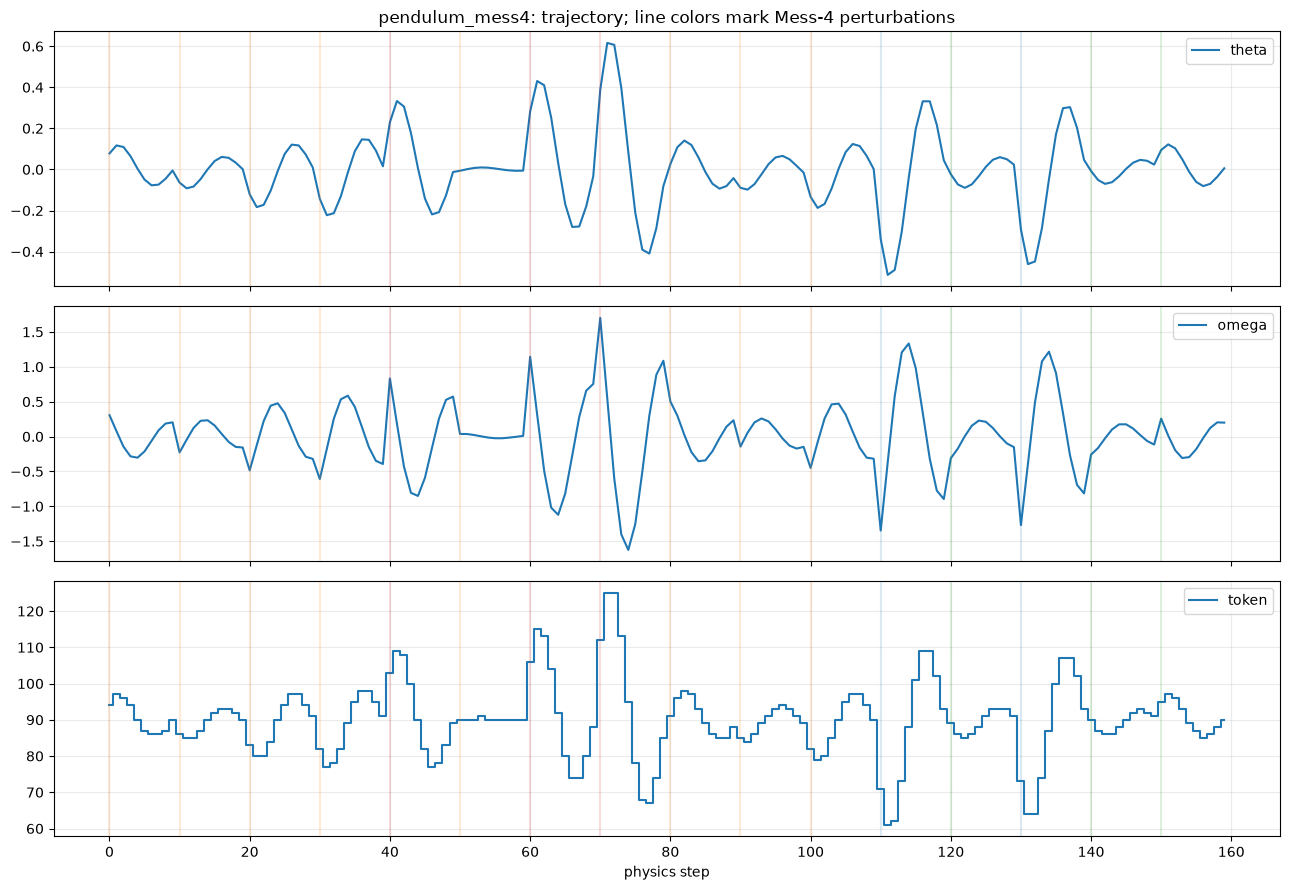

In [15]:
# Physics trajectory example generated from the selected initial-state mode.
i = 0
steps = np.arange(proc.seq_len)
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for c, name in enumerate(proc.channel_names):
    axes[0].plot(steps, batch['observable'][i, :, c], label=name)
for c, name in enumerate(proc.system.metric_names):
    axes[1].plot(steps, batch['metric'][i, :, c], label=name)
axes[2].step(steps, batch['tokens'][i], where='mid', label='token')
for ax in axes:
    for tick, letter in enumerate(batch['letters'][i]):
        ax.axvline(EXPERIMENT_CONFIG.impulse_positions[tick], color=f'C{letter}', alpha=0.16)
    ax.grid(alpha=0.25); ax.legend(loc='upper right')
axes[0].set_title(f'{PROCESS_NAME}: trajectory; line colors mark Mess-4 perturbations')
axes[-1].set_xlabel('physics step')
plt.tight_layout()
plt.show()

### Visualize the HMM and exact belief

This cell draws the Mess-4 state graph, transition and emission matrices, and the exact predictive belief over hidden HMM states. It also prints the sampled HMM states and emitted perturbation letters for direct inspection.

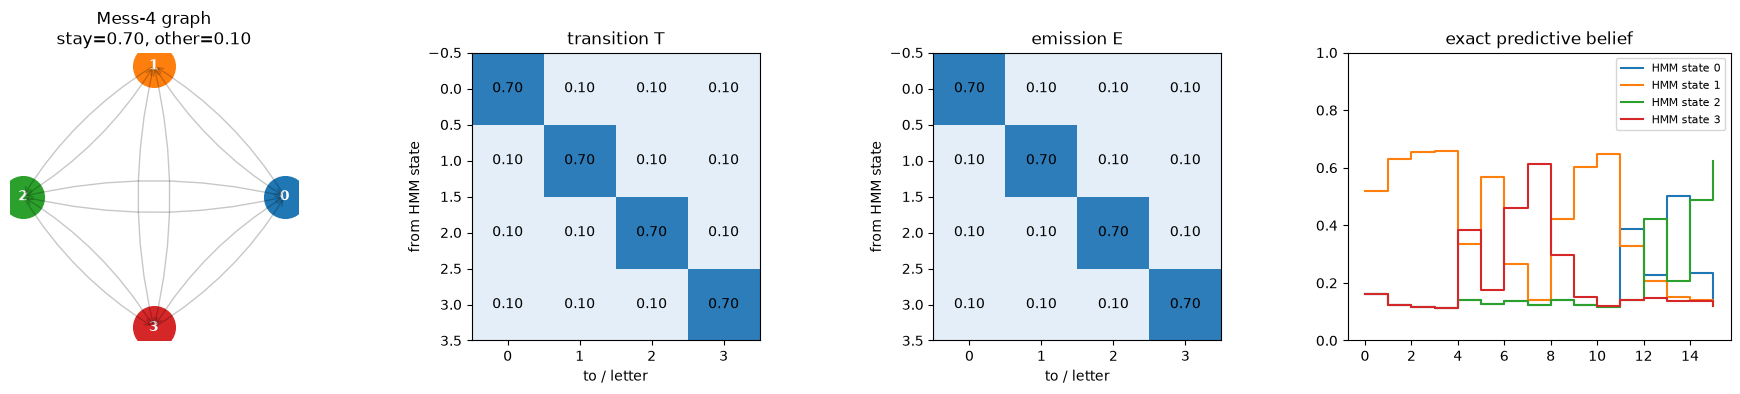

hidden HMM states: [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 2, 0, 2, 2, 3]
emitted letters: [1, 1, 1, 1, 3, 1, 3, 3, 1, 1, 1, 0, 2, 0, 2, 2]


In [16]:
# HMM transition graph, matrices, sampled outputs, and exact belief trajectory.
chain = proc.chain
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
angles = np.linspace(0, 2 * np.pi, chain.n_states, endpoint=False)
xy = np.c_[np.cos(angles), np.sin(angles)]
ax = axes[0]
for state, (x, y) in enumerate(xy):
    ax.scatter(x, y, s=900, color=f'C{state}', zorder=3)
    ax.text(x, y, str(state), ha='center', va='center', color='white', weight='bold')
for source in range(chain.n_states):
    for target in range(chain.n_states):
        if source == target:
            continue
        ax.annotate('', xy=xy[target], xytext=xy[source],
                    arrowprops={'arrowstyle': '->', 'alpha': 0.22, 'connectionstyle': 'arc3,rad=.12'})
ax.set_title(f'Mess-4 graph\nstay={chain.stay:.2f}, other={chain.x:.2f}')
ax.set_axis_off(); ax.set_aspect('equal')
for matrix, title, matrix_ax in ((chain.T, 'transition T', axes[1]), (chain.E, 'emission E', axes[2])):
    im = matrix_ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues')
    for row in range(chain.n_states):
        for col in range(chain.n_states):
            matrix_ax.text(col, row, f'{matrix[row, col]:.2f}', ha='center', va='center')
    matrix_ax.set_title(title); matrix_ax.set_xlabel('to / letter'); matrix_ax.set_ylabel('from HMM state')
belief_tick = batch['beliefs'][0, EXPERIMENT_CONFIG.n - 1::EXPERIMENT_CONFIG.n]
for state in range(chain.n_states):
    axes[3].step(np.arange(proc.m), belief_tick[:, state], where='post', label=f'HMM state {state}')
axes[3].set_ylim(0, 1); axes[3].set_title('exact predictive belief'); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('hidden HMM states:', batch['hmm_state_path'][0].tolist())
print('emitted letters:', batch['letters'][0].tolist())

### Check coverage, beliefs, and stability

This cell summarizes vocabulary coverage, clipping, belief entropy and normalization, memory length, and simulator stability. Assertions stop the notebook if probabilities, token ranges, or physical values are invalid.

In [17]:
# Physics/HMM statistics and stability checks across all experiment configs.
summary_rows = []
for exp_cfg in EXPERIMENT_CONFIGS:
    p = exp_cfg.build_process()
    b = sample_physics_batch(p, np.random.default_rng(exp_cfg.seed), exp_cfg.n_trajectories, exp_cfg=exp_cfg)
    b_bins = p.bin_report(b['observable'])
    b_trace = V.trace(p, seed=exp_cfg.seed)
    b_stable = V.stability(b_trace)
    b_belief = b['beliefs'].reshape(-1, p.chain.n_states)
    norm_err = float(np.abs(b_belief.sum(1) - 1).max())
    entropy_frac = float(-(b_belief * np.log(np.clip(b_belief, 1e-12, None))).sum(1).mean() / np.log(p.chain.n_states))
    row = {
        'experiment_config': exp_cfg.name, 'system': exp_cfg.process_name,
        'hmm_states': p.chain.n_states, 'hmm_alpha': p.chain.alpha, 'hmm_stay': p.chain.stay,
        'k_lookahead': TRAINING_CONFIGS[0].k,
        'initial_state_mode': exp_cfg.initial_state.mode,
        'sequences': len(b['tokens']), 'sequence_length': p.seq_len,
        'vocabulary': p.n_obs, 'used_bins': b_bins['used_bins'], 'clipped_fraction': b_bins['clipped'],
        'belief_normalization_error': norm_err,
        'belief_entropy_fraction': entropy_frac,
        'belief_memory_letters': p.chain.memory_length(), 'lyapunov': b_stable['lyapunov'],
        'baseline_stable': b_stable['stable'], 'stability_reasons': b_stable['reasons'],
        'm_impulse_cycles': exp_cfg.m, 'n_impulse_spacing': exp_cfg.n,
        'trajectory_tokens': p.seq_len, 'dt_physics_sampling_gap': p.dt,
        'integration_dt': exp_cfg.physics.integration_dt,
        'physics_iterations_per_sampling_gap': round(p.dt / exp_cfg.physics.integration_dt),
        'delta_v': p.delta_v,
    }
    summary_rows.append(row)
    assert np.allclose(p.chain.T.sum(1), 1) and np.allclose(p.chain.E.sum(1), 1)
    assert norm_err < 1e-10
    assert b['tokens'].min() >= 0 and b['tokens'].max() < p.n_obs
    assert np.isfinite(b['observable']).all() and np.isfinite(b['metric']).all()
    assert p.seq_len == exp_cfg.trajectory_tokens
    assert exp_cfg.impulse_positions == tuple(i * exp_cfg.n for i in range(exp_cfg.m))
    b_cycles = b['beliefs'].reshape(len(b['beliefs']), exp_cfg.m, exp_cfg.n, -1)
    assert np.allclose(b_cycles, b_cycles[:, :, :1]), 'one HMM state must govern each n-token impulse cycle'
    integration_steps = round(p.dt / exp_cfg.physics.integration_dt)
    z0 = p.system.base.initial_state(2)
    assert np.allclose(p.system.flow(z0, p.dt), p.system.base.flow(z0, p.dt, substeps=integration_steps))

display(pd.DataFrame(summary_rows))

,experiment_config,system,hmm_states,hmm_alpha,hmm_stay,k_lookahead,initial_state_mode,sequences,sequence_length,vocabulary,...,lyapunov,baseline_stable,stability_reasons,m_impulse_cycles,n_impulse_spacing,trajectory_tokens,dt_physics_sampling_gap,integration_dt,physics_iterations_per_sampling_gap,delta_v
0,cleandriven,pendulum_mess4,4,0.7,0.7,1,fixed,256,160,181,...,-0.396040,True,[],16,10,160,0.20,0.01,20,0.550000
1,default,pendulum_mess4,4,0.7,0.7,1,fixed,256,160,181,...,-0.536764,True,[],16,10,160,0.02,0.01,2,0.547723


### Package samples for PyTorch

This cell wraps a finite diagnostic batch in a `Dataset` and stacks rows with the correct integer or floating-point dtype. A small `DataLoader` batch verifies the shapes expected downstream.

In [18]:
# Finite dataset and collator for inspection/evaluation. Training below deliberately streams fresh batches.
class PhysicsDataset(Dataset):
    def __init__(self, proc, n_trajectories, seed):
        self.batch = sample_physics_batch(proc, np.random.default_rng(seed), n_trajectories)
    def __len__(self):
        return len(self.batch['tokens'])
    def __getitem__(self, index):
        return {name: values[index] for name, values in self.batch.items()}

def physics_collate(rows):
    out = {}
    for name in rows[0]:
        values = np.stack([row[name] for row in rows])
        dtype = torch.long if np.issubdtype(values.dtype, np.integer) else torch.float32
        out[name] = torch.as_tensor(values, dtype=dtype)
    return out

dataset = PhysicsDataset(proc, N_DATA_TRAJECTORIES, DATA_SEED + 1)
loader = DataLoader(dataset, batch_size=min(8, len(dataset)), shuffle=False, collate_fn=physics_collate)
loader_batch = next(iter(loader))
print({k: (tuple(v.shape), str(v.dtype)) for k, v in loader_batch.items()})
assert loader_batch['tokens'].shape[1:] == (proc.seq_len,)
assert loader_batch['beliefs'].shape[1:] == (proc.seq_len, chain.n_states)
assert loader_batch['tokens'].dtype == torch.long

{'tokens': ((8, 160), 'torch.int64'), 'observable': ((8, 160, 1), 'torch.float32'), 'metric': ((8, 160, 1), 'torch.float32'), 'letters': ((8, 16), 'torch.int64'), 'beliefs': ((8, 160, 4), 'torch.float32'), 'hmm_state_path': ((8, 17), 'torch.int64'), 'initial_state': ((8, 2), 'torch.float32')}


## Phase 2 — transformer

This phase trains a causal transformer to predict the discretized observation `k` timestamps ahead. Its logits at position `t` are scored against token `t+k`; `k=1` recovers ordinary next-token prediction. Training streams freshly sampled physics batches, so the model does not repeatedly optimize on the finite diagnostic dataset from Phase 1.

`TRAINING_CONFIGS` supports multiple seeds or architectures by adding `TrainingConfig` instances, although the default contains one configuration. The phase plots train/evaluation loss and inspects full token probabilities, not just argmax accuracy. Intermediate checkpoints are skipped; each run saves exactly one final transformer.

### Train configurations and save final weights

For each entry in `TRAINING_CONFIGS`, this cell creates matched trained and random-initialized transformers, verifies that the loss targets token `t+k`, trains on fresh token batches, and writes only the final state dictionary plus a JSON metadata sidecar.

In [19]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
trained_runs = {}
for exp_cfg in EXPERIMENT_CONFIGS:
    proc = exp_cfg.build_process()
    for run in TRAINING_CONFIGS:
        run_key = f'{exp_cfg.name}_{run.name}'
        cfg = run.model_config(proc)
        random_model = run.build_model(proc)
        model = run.build_model(proc)
        model.load_state_dict(random_model.state_dict())
        sanity_tokens = torch.as_tensor(
            sample_physics_batch(proc, np.random.default_rng(run.seed), 2, exp_cfg=exp_cfg)['tokens'],
            dtype=torch.long,
        )
        with torch.no_grad():
            sanity_logits = random_model(sanity_tokens)
            manual_k_loss = torch.nn.functional.cross_entropy(
                sanity_logits[:, :-run.k].reshape(-1, proc.n_obs), sanity_tokens[:, run.k:].reshape(-1))
        assert torch.allclose(random_model.loss(sanity_tokens), manual_k_loss), 'k must shift the training target'
        report = train(
            model,
            lambda rng, batch_size, p=proc, ec=exp_cfg: sample_physics_batch(p, rng, batch_size, exp_cfg=ec)['tokens'],
            proc.seq_len,
            run.train_config(),
            device=DEVICE,
        )
        final_path = OUTPUT_DIR / f'{exp_cfg.name}_{run.name}_seed{run.seed}_final.pt'
        torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, final_path)
        metadata = {
            'process': exp_cfg.process_name, 'experiment': exp_cfg.metadata(),
            'model': asdict(cfg), 'training': asdict(run),
            'tokens_seen': report['tokens_seen'], 'final_loss': report['final'],
        }
        final_path.with_suffix('.json').write_text(json.dumps(metadata, indent=2))
        run_entry = {
            'model': model.eval(), 'random_model': random_model.eval(),
            'config': cfg, 'report': report, 'path': final_path,
            'experiment_config': exp_cfg, 'training_config': run,
            'proc': proc, 'run_name': run_key,
        }
        trained_runs[run_key] = run_entry
        if len(EXPERIMENT_CONFIGS) == 1:
            trained_runs[run.name] = run_entry
        print(run_key, 'saved', final_path, report['final'])

assert all(run['path'].exists() for run in trained_runs.values())

train:   0%|          | 0/97656 [00:00<?, ?it/s]

cleandriven_shorttrain saved /home/manjot/Files/Code/BeliefPhysics/Belief-in-physics/experiments/outputs-three-phase/cleandriven_shorttrain_seed0_final.pt {'step': 97655, 'train_loss': 0.13775961101055145, 'eval_loss': 0.137729674577713}


train:   0%|          | 0/29296 [00:00<?, ?it/s]

cleandriven_longtrain saved /home/manjot/Files/Code/BeliefPhysics/Belief-in-physics/experiments/outputs-three-phase/cleandriven_longtrain_seed0_final.pt {'step': 29295, 'train_loss': 0.15443968772888184, 'eval_loss': 0.15570761263370514}


train:   0%|          | 0/97656 [00:00<?, ?it/s]

default_shorttrain saved /home/manjot/Files/Code/BeliefPhysics/Belief-in-physics/experiments/outputs-three-phase/default_shorttrain_seed0_final.pt {'step': 97655, 'train_loss': 0.45922544598579407, 'eval_loss': 0.46460336446762085}


train:   0%|          | 0/29296 [00:00<?, ?it/s]

default_longtrain saved /home/manjot/Files/Code/BeliefPhysics/Belief-in-physics/experiments/outputs-three-phase/default_longtrain_seed0_final.pt {'step': 29295, 'train_loss': 0.5146239399909973, 'eval_loss': 0.5134777426719666}


### Inspect the loss curve

This cell plots training and evaluation cross-entropy for every run at its configured lookahead `k`. The dotted `log(vocabulary size)` line is the loss expected from uniform guessing.

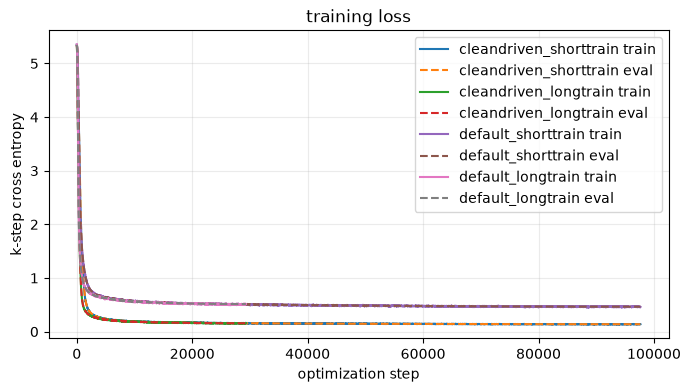

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
plotted = set()
for key, run in trained_runs.items():
    name = run['run_name']
    if name in plotted:
        continue
    plotted.add(name)
    h = pd.DataFrame(run['report']['history'])
    ax.plot(h['step'], h['train_loss'], label=f'{name} train')
    ax.plot(h['step'], h['eval_loss'], '--', label=f'{name} eval')
if len(EXPERIMENT_CONFIGS) == 1:
    ax.axhline(np.log(EXPERIMENT_CONFIGS[0].build_process().n_obs), color='0.4', ls=':', label='uniform')
ax.set(xlabel='optimization step', ylabel='k-step cross entropy', title='training loss')
ax.legend(); ax.grid(alpha=.25); plt.show()

### Inspect actual k-step-ahead predictions

This cell evaluates a fresh trajectory and aligns each prediction at position `t` with the true token at `t+k`. It compares token IDs and decoded physical values, then plots the complete probability heatmap; normalization and finite negative log-likelihood are checked explicitly.

,actual_token,predicted_token,actual_value,predicted_value
0,97,97,[0.122],[0.122]
1,96,96,[0.105],[0.105]
2,94,94,[0.07],[0.07]
3,90,90,[0.0],[0.0]
4,87,87,[-0.052],[-0.052]
5,86,86,[-0.07],[-0.07]
6,86,86,[-0.07],[-0.07]
7,87,87,[-0.052],[-0.052]
8,90,90,[0.0],[0.0]
9,75,86,[-0.262],[-0.07]


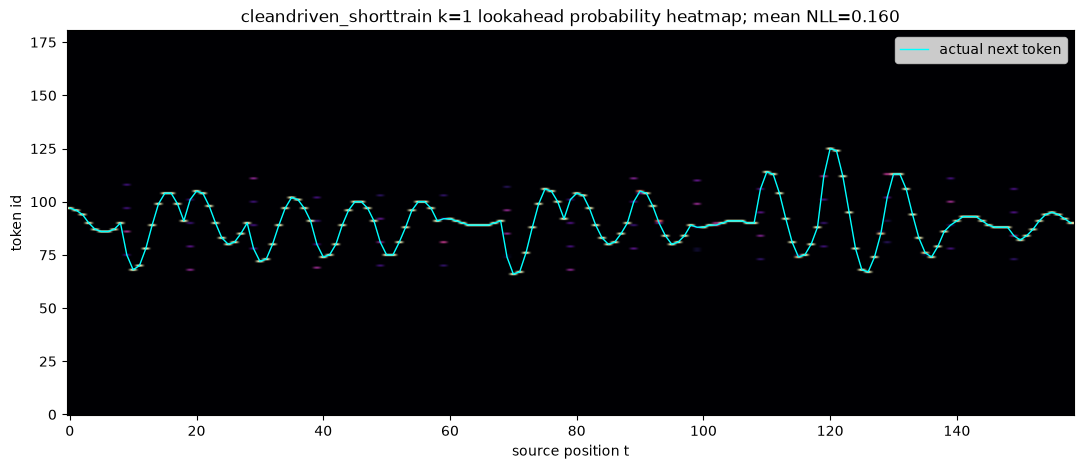

In [21]:
# Direct model sanity check: k-step token outputs and a probability heatmap.
chosen_key = f'{EXPERIMENT_CONFIGS[0].name}_{TRAINING_CONFIGS[0].name}'
chosen = trained_runs[chosen_key]
model = chosen['model']
k = chosen['training_config'].k
chosen_exp = chosen['experiment_config']
chosen_proc = chosen['proc']
check = sample_physics_batch(chosen_proc, np.random.default_rng(chosen_exp.seed + 2), 4, exp_cfg=chosen_exp)
tokens = check['tokens'][0]
probs = token_probabilities(model, tokens, DEVICE)
predicted = probs[:-k].argmax(1)
actual = tokens[k:]
nll = -np.log(np.maximum(probs[:-k, :][np.arange(len(actual)), actual], 1e-12))
decoded_actual = chosen_proc.undiscretise(actual[:24])
decoded_predicted = chosen_proc.undiscretise(predicted[:24])
display(pd.DataFrame({
    'actual_token': actual[:24], 'predicted_token': predicted[:24],
    'actual_value': [np.round(x, 3).tolist() for x in decoded_actual],
    'predicted_value': [np.round(x, 3).tolist() for x in decoded_predicted],
}))
fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(probs[:-k].T, origin='lower', aspect='auto', cmap='magma')
ax.plot(np.arange(len(actual)), actual, color='cyan', lw=1, label='actual next token')
ax.set(xlabel='source position t', ylabel='token id', title=f'{chosen_key} k={k} lookahead probability heatmap; mean NLL={nll.mean():.3f}')
ax.legend(); plt.show()
assert probs.shape == (chosen_proc.seq_len, chosen_proc.n_obs)
assert np.allclose(probs.sum(1), 1.0, atol=1e-5)
assert np.isfinite(nll).all()

## Phase 3 — ridge analysis

This phase asks whether transformer residual streams linearly expose the physical metric or the exact HMM belief. The transformer is frozen: standardized ridge regressions read its activations, with physics and belief fitted and scored separately.

Four feature formats are compared: one layer at one token, all layers at one token, one layer across a perturbation cycle, and all layers across a cycle. A “single token” is the final observation in each cycle. Ridge strength is selected with grouped cross-validation over complete trajectories, then measured on untouched trajectories. Every probe is repeated on the architecture-matched random transformer to establish a baseline.

### Define probe targets, feature views, and splits

This cell extracts end-of-cycle physics and simplex-embedded belief targets, defines the four residual-stream feature formats, and creates disjoint development and test trajectory groups to prevent sequence leakage.

In [22]:
chosen_exp = chosen['experiment_config']
chosen_proc = chosen['proc']

def probe_targets(batch, proc, exp_cfg=None):
    cfg = exp_cfg or getattr(proc, '_experiment_config', EXPERIMENT_CONFIGS[0])
    last = np.arange(cfg.n - 1, proc.seq_len, cfg.n)
    belief = batch['beliefs'][:, last] @ simplex_embedding(proc.chain.n_states)
    metric = batch['metric'][:, last]
    return {'physics': metric.reshape(-1, metric.shape[-1]),
            'belief': belief.reshape(-1, belief.shape[-1])}

def probe_features(streams, mode, proc, exp_cfg=None):
    cfg = exp_cfg or getattr(proc, '_experiment_config', EXPERIMENT_CONFIGS[0])
    selected = [streams[ANALYSIS_CONFIG.selected_layer]] if mode.startswith('single_layer') else streams
    return tick_features(selected, cfg.n, whole_tick=mode.endswith('cycle')).astype(np.float32)

# analysis_batch = sample_physics_batch(
#     chosen_proc, np.random.default_rng(chosen_exp.seed + 3), N_ANALYSIS_TRAJECTORIES, exp_cfg=chosen_exp
# )
# targets = probe_targets(analysis_batch, chosen_proc, chosen_exp)
# groups = np.repeat(np.arange(N_ANALYSIS_TRAJECTORIES), chosen_proc.m)
# order = np.random.default_rng(chosen_exp.seed + 4).permutation(N_ANALYSIS_TRAJECTORIES)
# n_test = max(1, int(N_ANALYSIS_TRAJECTORIES * ANALYSIS_CONFIG.test_fraction))
# test_sequences = set(order[:n_test].tolist())
# test_mask = np.array([g in test_sequences for g in groups])
# dev_mask = ~test_mask
# assert set(groups[dev_mask]).isdisjoint(set(groups[test_mask]))

### Fit grouped cross-validated ridge probes

This cell standardizes each feature matrix, chooses ridge regularization with `GroupKFold`, and reports untouched test R². It runs every feature format and target on both the trained and random transformers.

In [23]:
def cross_validated_ridge(X, y, groups, dev_mask, test_mask):
    estimator = make_pipeline(StandardScaler(), Ridge(solver='lsqr'))
    search = GridSearchCV(
        estimator, {'ridge__alpha': ANALYSIS_CONFIG.ridge_alphas},
        cv=GroupKFold(n_splits=ANALYSIS_CONFIG.cv_folds), scoring='r2', n_jobs=1,
    )
    search.fit(X[dev_mask], y[dev_mask], groups=groups[dev_mask])
    prediction = search.best_estimator_.predict(X[test_mask])
    return {
        'alpha': float(search.best_params_['ridge__alpha']),
        'cv_r2': float(search.best_score_),
        'test_r2': float(r2_score(y[test_mask], prediction, multioutput='uniform_average')),
        'feature_dim': X.shape[1],
        'dev_rows_per_feature': float(dev_mask.sum() / X.shape[1]),
    }

all_probe_rows = []
from tqdm import tqdm
for exp_cfg in tqdm(EXPERIMENT_CONFIGS):
    proc = exp_cfg.build_process()
    
    # 1. Sample evaluation trajectory batch and compute targets for this experiment
    analysis_batch = sample_physics_batch(
        proc, np.random.default_rng(exp_cfg.seed + 3), N_ANALYSIS_TRAJECTORIES, exp_cfg=exp_cfg
    )
    targets = probe_targets(analysis_batch, proc, exp_cfg)
    groups = np.repeat(np.arange(N_ANALYSIS_TRAJECTORIES), proc.m)
    order = np.random.default_rng(exp_cfg.seed + 4).permutation(N_ANALYSIS_TRAJECTORIES)
    n_test = max(1, int(N_ANALYSIS_TRAJECTORIES * ANALYSIS_CONFIG.test_fraction))
    test_sequences = set(order[:n_test].tolist())
    test_mask = np.array([g in test_sequences for g in groups])
    dev_mask = ~test_mask
    assert set(groups[dev_mask]).isdisjoint(set(groups[test_mask]))
    
    # 2. Probe every training configuration associated with this experiment
    for run in TRAINING_CONFIGS:
        run_key = f'{exp_cfg.name}_{run.name}'
        run_info = trained_runs[run_key]
        per_run_rows = []
        
        for model_tag, model_obj in (('trained', run_info['model']), ('random_init', run_info['random_model'])):
            streams = residual_streams_batched(model_obj.to(DEVICE).eval(), analysis_batch['tokens'], DEVICE)
            for mode in ANALYSIS_CONFIG.probe_modes:
                X = probe_features(streams, mode, exp_cfg)
                for target_name in ('physics', 'belief'):
                    score = cross_validated_ridge(X, targets[target_name], groups, dev_mask, test_mask)
                    row = {
                        'experiment': exp_cfg.name,
                        'system': exp_cfg.process_name,
                        'training': run.name,
                        'seed': run.seed,
                        'k_lookahead': run.k,
                        'd_model': run.d_model,
                        'n_layers': run.n_layers,
                        'model_type': model_tag,
                        'mode': mode,
                        'target': target_name,
                        **score,
                    }
                    per_run_rows.append(row)
                    all_probe_rows.append(row)
        
        # 3. Save per-run structured outputs side-by-side with model weights
        run_df = pd.DataFrame(per_run_rows)
        base_name = f'{exp_cfg.name}_{run.name}_seed{run.seed}_probes'
        csv_path = OUTPUT_DIR / f'{base_name}.csv'
        json_path = OUTPUT_DIR / f'{base_name}.json'
        
        run_df.to_csv(csv_path, index=False)
        json_path.write_text(json.dumps({
            'experiment': exp_cfg.metadata(),
            'training': asdict(run),
            'results': per_run_rows,
        }, indent=2))
        print(f"[{run_key}] Probing complete. Saved -> {csv_path.name}")

# 4. Save consolidated sweep results
probe_results = pd.DataFrame(all_probe_rows)
master_csv = OUTPUT_DIR / 'probe_results_all.csv'
probe_results.to_csv(master_csv, index=False)
print(f"\nWrote master probe dataset ({len(probe_results)} evaluations) to {master_csv.name}")

display(probe_results.head(20))


  0%|          | 0/2 [00:00<?, ?it/s]

[cleandriven_shorttrain] Probing complete. Saved -> cleandriven_shorttrain_seed0_probes.csv


 50%|█████     | 1/2 [16:08<16:08, 968.10s/it]

[cleandriven_longtrain] Probing complete. Saved -> cleandriven_longtrain_seed0_probes.csv
[default_shorttrain] Probing complete. Saved -> default_shorttrain_seed0_probes.csv


100%|██████████| 2/2 [26:48<00:00, 804.45s/it]

[default_longtrain] Probing complete. Saved -> default_longtrain_seed0_probes.csv

Wrote master probe dataset (64 evaluations) to probe_results_all.csv


,experiment,system,training,seed,k_lookahead,d_model,n_layers,model_type,mode,target,alpha,cv_r2,test_r2,feature_dim,dev_rows_per_feature
0,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,single_layer_single_token,physics,1.0,0.881639,0.877807,64,205.000000
1,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,single_layer_single_token,belief,10.0,0.724234,0.708210,64,205.000000
2,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,all_layers_single_token,physics,0.1,0.955821,0.954040,192,68.333333
3,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,all_layers_single_token,belief,1.0,0.824388,0.813835,192,68.333333
4,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,single_layer_cycle,physics,10.0,0.991228,0.991800,640,20.500000
5,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,single_layer_cycle,belief,50.0,0.933090,0.929548,640,20.500000
6,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,all_layers_cycle,physics,1.0,0.999934,0.999947,1920,6.833333
7,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,trained,all_layers_cycle,belief,10.0,0.974227,0.974518,1920,6.833333
8,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,random_init,single_layer_single_token,physics,10.0,0.814302,0.810653,64,205.000000
9,cleandriven,pendulum_mess4,shorttrain,0,1,64,2,random_init,single_layer_single_token,belief,1.0,0.441138,0.420540,64,205.000000


### Compare trained and random representations

This cell plots held-out R² by target and feature format, then computes the trained-minus-random improvement. Final assertions confirm that all requested modes, models, and targets produced finite scores.

model_type,experiment,training,mode,target,random_init,trained,trained_minus_random
0,cleandriven,longtrain,all_layers_cycle,belief,0.904921,0.966444,0.061523
2,cleandriven,longtrain,all_layers_single_token,belief,0.456523,0.817602,0.361079
4,cleandriven,longtrain,single_layer_cycle,belief,0.891615,0.932393,0.040778
6,cleandriven,longtrain,single_layer_single_token,belief,0.420540,0.743444,0.322904
1,cleandriven,longtrain,all_layers_cycle,physics,0.999864,0.999933,0.000069
3,cleandriven,longtrain,all_layers_single_token,physics,0.831872,0.956283,0.124411
5,cleandriven,longtrain,single_layer_cycle,physics,0.998563,0.992216,-0.006347
7,cleandriven,longtrain,single_layer_single_token,physics,0.810653,0.888712,0.078059
8,cleandriven,shorttrain,all_layers_cycle,belief,0.904921,0.974518,0.069596
10,cleandriven,shorttrain,all_layers_single_token,belief,0.456523,0.813835,0.357312


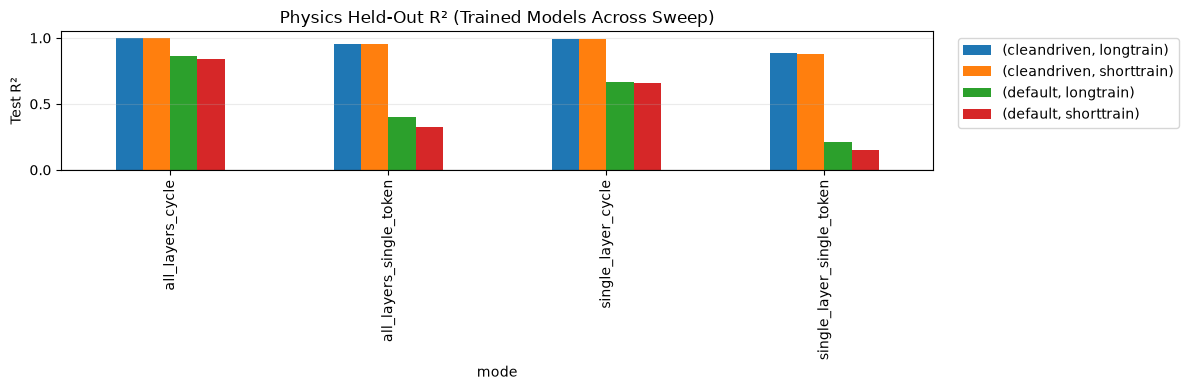

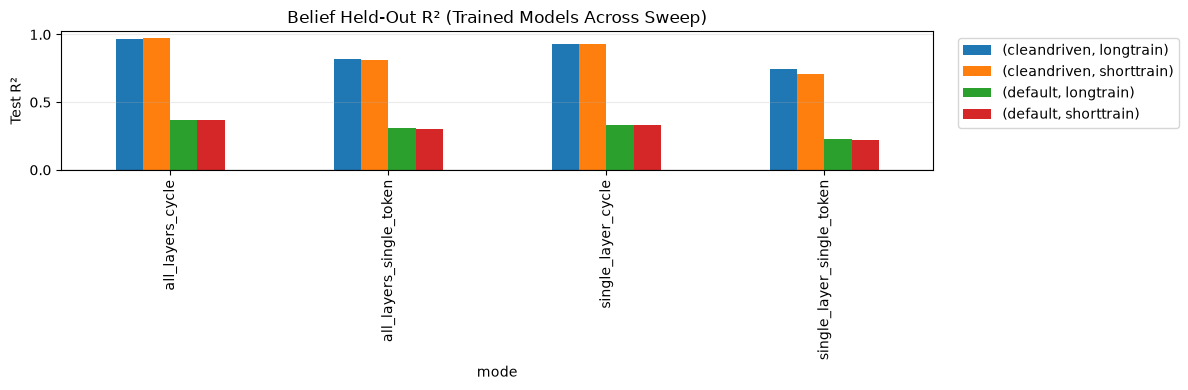

All probe evaluations completed with finite test and CV R² values.


In [24]:
# Aggregate view: compute trained vs random_init delta (improvement) for each run
summary_pivot = probe_results.pivot_table(
    index=['experiment', 'training', 'mode', 'target'],
    columns='model_type',
    values='test_r2',
).reset_index()

summary_pivot['trained_minus_random'] = summary_pivot['trained'] - summary_pivot['random_init']
display(summary_pivot.sort_values(['experiment', 'training', 'target', 'mode']))

# Plot held-out R2 comparisons across configurations
for target in ('physics', 'belief'):
    fig, ax = plt.subplots(figsize=(12, 4))
    subset = summary_pivot[summary_pivot.target == target]
    pivot_chart = subset.pivot(index='mode', columns=['experiment', 'training'], values='trained')
    pivot_chart.plot.bar(ax=ax)
    ax.axhline(0, color='black', lw=0.8)
    ax.set(title=f'{target.capitalize()} Held-Out R² (Trained Models Across Sweep)', ylabel='Test R²')
    ax.grid(axis='y', alpha=0.25)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

assert np.isfinite(probe_results[['cv_r2', 'test_r2']]).all().all()
print("All probe evaluations completed with finite test and CV R² values.")


## What is saved

Only each run’s final transformer and a JSON sidecar are written to `experiments/outputs-three-phase/` locally or `/kaggle/working/outputs-three-phase/` on Kaggle; `BELIEF_NOTEBOOK_OUTPUT_DIR` overrides either location. The sidecar serializes the complete `ExperimentConfig`, selected concrete physics class, `HMMConfig`, `TrainingConfig`, model shape, token count, and final losses, so every artifact retains its generating recipe. The random baseline is recreated from the same model seed. Phase 3 is deliberately a sanity analysis; the complete saved-weight analysis belongs in the later analysis notebook.